---
title: Michelson Interferometers, Modulations, and Transfer Functions - Homework 03
date: 2025-03-02
authors:
  - name: Alex Correia
    affiliations:
      - Syracuse University
---

In [1]:
%matplotlib widget
import numpy as np
import sympy

from ipywidgets import *
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use('dark_background')

fontsize = 14
mpl.rcParams.update(
    {
        "text.usetex": True,
        "figure.figsize": (9, 6),
        "figure.autolayout": True,
        "font.family": "serif",
        "font.serif": "georgia",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)

# Homodyne Michelson

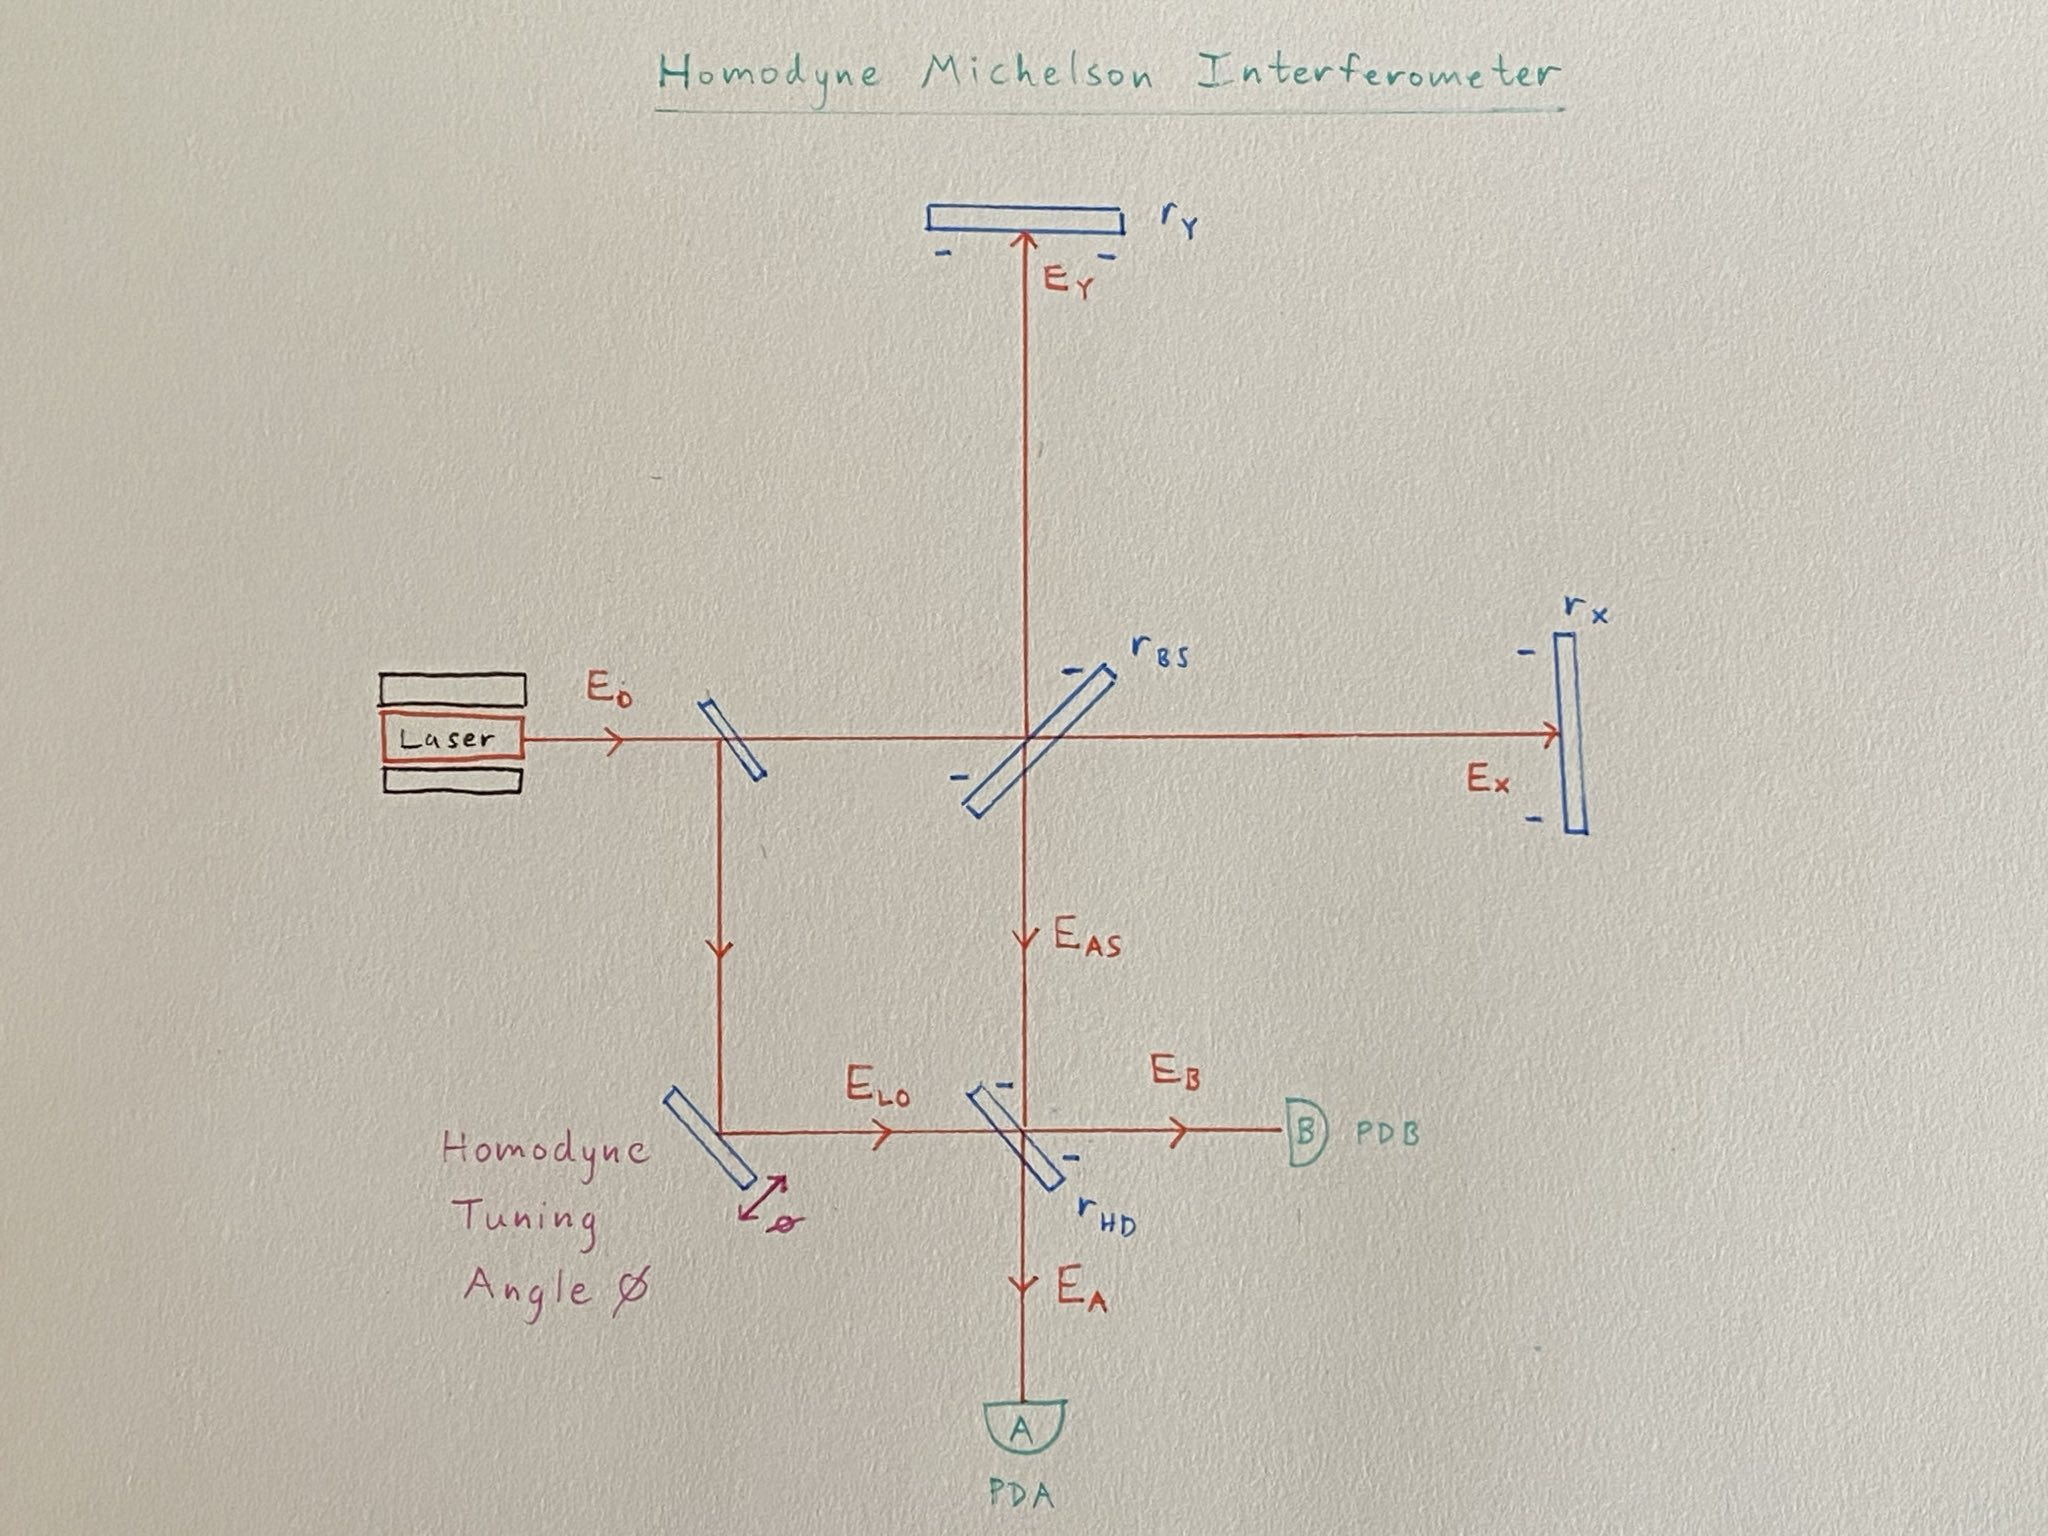

Homodyne Michelson Interferometer Diagram

## Adjacency Matrix
Set up an Adjacency Matrix $\boldsymbol{M}$ for the Homodyne Michelson.\
You may choose any electric fields vector you want, but you have to include the explicitly labeled electric fields.\
The homodyne angle $\phi_\mathrm{HD}$ can be considered as the total phase accrued by the local oscillator field $E_\mathrm{LO}$ in the pick-off path:
\begin{align}
E_\mathrm{LO} = -r_\mathrm{LO} e^{-i \phi_\mathrm{HD}} E_\mathrm{in}
\end{align}

First, consider the directed graph of the central Michelson interferometer. We neglect any outgoing fields that do not ultimately contribute to the photodiode signals; in this case, this means we neglect the beam $E_{\text{refl}}$ that would travel parallel to the input. We also assume that there is some transmission coefficient $t_{LO}$ associated with passing through the first beam splitter that sets up the pick-off path.

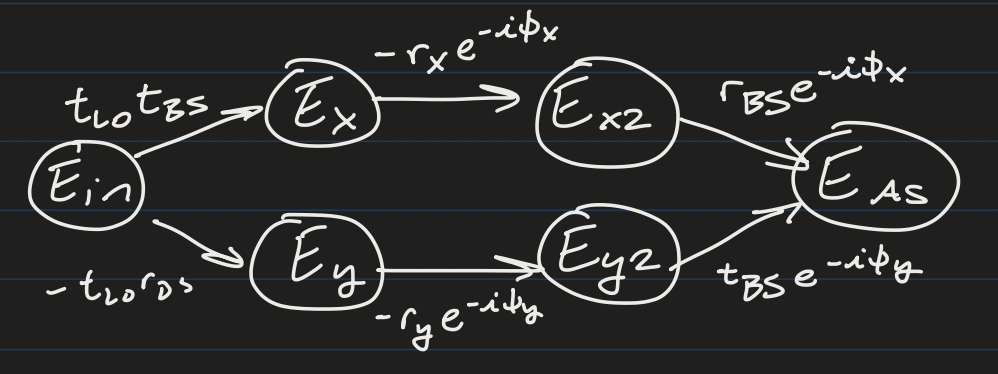

We define $\phi_x = kL_x$ and $\phi_y = kL_y$ as the total phase shift due to the beams traveling along the $X$ and $Y$ arms respectively. The intermediary steps $E_{i2}$ representing the reflected arm beams incident to the beamsplitter, we can simplify this as follows:
1) The $X$ contribution to $E_{AS}$ is $r_{BS}e^{-i\phi_x}E_{x2}.$ However, $E_{x2} = -r_{x}e^{-i\phi_x}E_x$, so the $X$ contribution becomes $-r_{x}r_{BS}e^{-2i\phi_x}E_x.$
2) Similarly, the $Y$ contribution is $t_{BS}e^{-i\phi_y}E_{y2}$, but using $E_{y2} = -r_{y}e^{-i\phi_y}E_y$ we can rewrite as $-r_{y}t_{BS}e^{-2i\phi_y}E_y.$

This leads to the simplified directed graph below, only in terms of the fields labeled above. Here, we ignore any additional phase shift due to the spatial displacement between the Michelson and photodiode beam splitters.

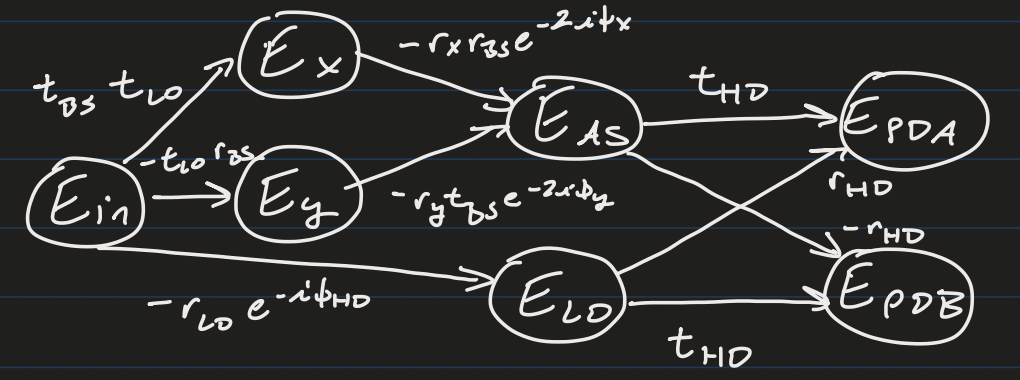

Converting this to matrix form:
\begin{equation}
\begin{bmatrix}
E_{in} \\
E_x \\
E_y \\
E_{LO} \\
E_{AS} \\
E_{PDA} \\
E_{PDB} \\
\end{bmatrix} = \begin{bmatrix}
0 & 0 & 0 & 0 & 0 & 0 & 0 \\
t_{BS}t_{LO} & 0 & 0 & 0 & 0 & 0 & 0 \\
-r_{BS}t_{LO} & 0 & 0 & 0 & 0 & 0 & 0 \\
-r_{LO}e^{-i\phi_{HD}} & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & -r_{x}r_{BS}e^{-2i\phi_x} & -r_{y}t_{BS}e^{-2i\phi_y} & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & r_{HD} & t_{HD} & 0 & 0 \\
0 & 0 & 0 & t_{HD} & -r_{HD} & 0 & 0 \\
\end{bmatrix}
\begin{bmatrix}
E_{in} \\
E_x \\
E_y \\
E_{LO} \\
E_{AS} \\
E_{PDA} \\
E_{PDB} \\
\end{bmatrix}
\end{equation}

## Electric Field Transfer Functions
Invert your Adjacency Matrix minus the identity $(\boldsymbol{M} - \boldsymbol{I})^{-1}$ to calculate the transfer functions from each electric field to every other electric field.\
Pick out the field transfer functions from the input to the photodetectors $\mathrm{PD}_A$ and $\mathrm{PD}_B$ $\dfrac{E_\mathrm{PDA}}{E_\mathrm{in}}$ and 
$\dfrac{E_\mathrm{PDB}}{E_\mathrm{in}}$.

The inverse can be found by plugging the matrix into Sympy. 

In [2]:
# invert with sympy
t_bs, r_bs, r_x, r_y, r_hd, t_hd, r_lo, t_lo = sympy.symbols('t_{BS} r_{BS} r_x r_y r_{HD}, t_{HD} r_{LO} t_{LO}', positive=True)
phi_x, phi_y, phi_hd = sympy.symbols('phi_x phi_y phi_hd', real=True)

# M minus identity
mat = sympy.Matrix([[-1, 0, 0, 0, 0, 0, 0],
                    [t_bs*t_lo, -1, 0, 0, 0, 0, 0],
                    [-r_bs*t_lo, 0, -1, 0, 0, 0, 0],
                    [-r_lo*sympy.exp(-1j*phi_hd), 0, 0, -1, 0, 0, 0],
                    [0, -r_x*r_bs*sympy.exp(-2j*phi_x), -r_y*t_bs*sympy.exp(-2j*phi_y), 0, -1, 0, 0],
                    [0, 0, 0, r_hd, t_hd, -1, 0],
                    [0, 0, 0, t_hd, -r_hd, 0, -1]])

# we want to invert (I - M) to get transfer functions
minv = (-mat)**-1

In [3]:
-mat

Matrix([
[                        1,                            0,                            0,       0,       0, 0, 0],
[           -t_{BS}*t_{LO},                            1,                            0,       0,       0, 0, 0],
[            r_{BS}*t_{LO},                            0,                            1,       0,       0, 0, 0],
[r_{LO}*exp(-1.0*I*phi_hd),                            0,                            0,       1,       0, 0, 0],
[                        0, r_x*r_{BS}*exp(-2.0*I*phi_x), r_y*t_{BS}*exp(-2.0*I*phi_y),       0,       1, 0, 0],
[                        0,                            0,                            0, -r_{HD}, -t_{HD}, 1, 0],
[                        0,                            0,                            0, -t_{HD},  r_{HD}, 0, 1]])

In [4]:
sympy.simplify(minv)

Matrix([
[                                                                                                                                        1,                                    0,                                    0,      0,       0, 0, 0],
[                                                                                                                            t_{BS}*t_{LO},                                    1,                                    0,      0,       0, 0, 0],
[                                                                                                                           -r_{BS}*t_{LO},                                    0,                                    1,      0,       0, 0, 0],
[                                                                                                               -r_{LO}*exp(-1.0*I*phi_hd),                                    0,                                    0,      1,       0, 0, 0],
[                              

In [5]:
# check that this is actually the inverse
sympy.simplify(-mat * minv)

Matrix([
[1, 0, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0],
[0, 0, 1, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 1, 0, 0],
[0, 0, 0, 0, 0, 1, 0],
[0, 0, 0, 0, 0, 0, 1]])

We can pick out the transfer functions to $E_{PDA}/E_{in}$ and $E_{PDB}/E_{in}$ from the first column, sixth and seventh rows respectively:
$$\frac{E_{PDA}}{E_{in}} = -r_x r_{BS} t_{BS} t_{LO} t_{HD}e^{-2i\phi_x} + r_y r_{BS} t_{BS} t_{LO} t_{HD}e^{-2i\phi_y} - r_{HD} r_{LO} e^{-i\phi_{hd}}$$
$$\frac{E_{PDB}}{E_{in}} = r_x r_{BS} t_{BS} t_{LO} r_{HD}e^{-2i\phi_x} - r_y r_{BS} t_{BS} t_{LO} r_{HD}e^{-2i\phi_y} - t_{HD} r_{LO} e^{-i\phi_{hd}}.$$

## Substitutions
Apply the phase change of basis used in class $\phi_d = \phi_x - \phi_y$ and $\phi_c = \phi_x + \phi_y$ to your field transfer functions above. (The original change of basis leaves an additional factor of 2 in all of the phasor angles; this basis matches lecture and makes the end result look nicer.)\
You may also assume a perfect Michelson beamsplitter $r_\mathrm{BS} = t_\mathrm{BS} = \dfrac{1}{\sqrt{2}}$.

Making the above substitutions and doing the algebra for the case of $E_{PDA}$:
\begin{align}
\frac{E_{PDA}}{E_{in}} &= -\frac{1}{2}r_xt_{HD}t_{LO}e^{-i(\phi_c + \phi_d)} +\frac{1}{2}r_yt_{HD}t_{LO}e^{-i(\phi_c - \phi_d)} - r_{HD}r_{LO}e^{-i\phi_{hd}} \\
&= -\frac{t_{HD}t_{LO}}{2}e^{-i\phi_c}\bigg[ r_xe^{-i\phi_d} - r_ye^{i\phi_d} \bigg] - r_{HD}r_{LO}e^{-i\phi_{hd}} \\
&= -\frac{t_{HD}t_{LO}}{2}e^{-i\phi_c}\bigg[ (r_x - r_y)\cos \phi_d - i(r_x + r_y)\sin \phi_d \bigg] - r_{HD}r_{LO}e^{-i\phi_{hd}}.
\end{align}
If we define a differential reflectivity basis
$$r_c = \frac{r_x + r_y}{2}, r_d = \frac{r_x - r_y}{2},$$
we can rewrite the above as
$$\frac{E_{PDA}}{E_{in}} = -t_{HD}t_{LO}e^{-i\phi_c}\bigg[ r_d\cos \phi_d - ir_c\sin \phi_d \bigg] - r_{HD}r_{LO}e^{-i\phi_{hd}}$$
Similarly, for $E_{PDB}$:
\begin{align}
\frac{E_{PDB}}{E_{in}} &= \frac{1}{2}r_xr_{HD}t_{LO}e^{-i(\phi_c + \phi_d)} - \frac{1}{2}r_yr_{HD}t_{LO}e^{-i(\phi_c - \phi_d)} - t_{HD}r_{LO}e^{-i\phi_{hd}} \\
&= \frac{r_{HD}t_{LO}}{2}e^{-i\phi_c}\bigg[ r_xe^{-i\phi_d} - r_ye^{i\phi_d} \bigg] - t_{HD}r_{LO}e^{-i\phi_{hd}} \\
&= \frac{r_{HD}t_{LO}}{2}e^{-i\phi_c}\bigg[ (r_x - r_y)\cos \phi_d - i(r_x + r_y)\sin \phi_d \bigg] - t_{HD}r_{LO}e^{-i\phi_{hd}} \\
&= r_{HD}t_{LO}e^{-i\phi_c}\bigg[ r_d\cos \phi_d - ir_c\sin \phi_d \bigg] - t_{HD}r_{LO}e^{-i\phi_{hd}}
\end{align}
Notice that the first term in both fields resembles the result from Eq. 21 in the lectures, which describes the antisymmetric port field of a regular Michelson with a contrast defect. In fact, if we got rid of the homodyning and set $t_{HD} = t_{LO} = 1$ then $E_{PDA}$ would match this exactly.

## Power Transfer Functions
Calculate the input to power transfer functions $\dfrac{P_\mathrm{PDA}}{P_\mathrm{in}}$ and $\dfrac{P_\mathrm{PDB}}{P_\mathrm{in}}$.

Taking the modulus of the above expressions will be a bit messy by-hand so we'll use Sympy:

In [6]:
# define the functions
r_c, r_d = sympy.symbols('r_c r_d', positive=True)
phi_c, phi_d = sympy.symbols('phi_c phi_d', real=True)

# sympy is weird about simplifying complex exps and trig fns...just write it all out as trig
E_pda = -t_hd * t_lo * (sympy.cos(phi_c) - 1j * sympy.sin(phi_c)) * (r_d * sympy.cos(phi_d) - 1j * r_c * sympy.sin(phi_d)) - \
            r_hd * r_lo * (sympy.cos(phi_hd) - 1j * sympy.sin(phi_hd))
E_pdb = r_hd * t_lo * (sympy.cos(phi_c) - 1j * sympy.sin(phi_c)) * (r_d * sympy.cos(phi_d) - 1j * r_c * sympy.sin(phi_d)) - \
            t_hd * r_lo * (sympy.cos(phi_hd) - 1j * sympy.sin(phi_hd))
E_pda

-r_{HD}*r_{LO}*(-1.0*I*sin(phi_hd) + cos(phi_hd)) - t_{HD}*t_{LO}*(-1.0*I*sin(phi_c) + cos(phi_c))*(-1.0*I*r_c*sin(phi_d) + r_d*cos(phi_d))

In [7]:
E_pdb

r_{HD}*t_{LO}*(-1.0*I*sin(phi_c) + cos(phi_c))*(-1.0*I*r_c*sin(phi_d) + r_d*cos(phi_d)) - r_{LO}*t_{HD}*(-1.0*I*sin(phi_hd) + cos(phi_hd))

In [8]:
# take magnitude squared to get power
P_pda = sympy.Abs(E_pda)**2
sympy.simplify(sympy.simplify(P_pda))

1.0*r_c**2*t_{HD}**2*t_{LO}**2*sin(phi_d)**2 - 2.0*r_c*r_{HD}*r_{LO}*t_{HD}*t_{LO}*sin(phi_d)*sin(phi_c - phi_hd) - 1.0*r_d**2*t_{HD}**2*t_{LO}**2*sin(phi_d)**2 + 1.0*r_d**2*t_{HD}**2*t_{LO}**2 + 2.0*r_d*r_{HD}*r_{LO}*t_{HD}*t_{LO}*cos(phi_d)*cos(phi_c - phi_hd) + 1.0*r_{HD}**2*r_{LO}**2

In [9]:
P_pdb = sympy.Abs(E_pdb)**2
sympy.simplify(sympy.simplify(P_pdb))

1.0*r_c**2*r_{HD}**2*t_{LO}**2*sin(phi_d)**2 + 2.0*r_c*r_{HD}*r_{LO}*t_{HD}*t_{LO}*sin(phi_d)*sin(phi_c - phi_hd) - 1.0*r_d**2*r_{HD}**2*t_{LO}**2*sin(phi_d)**2 + 1.0*r_d**2*r_{HD}**2*t_{LO}**2 - 2.0*r_d*r_{HD}*r_{LO}*t_{HD}*t_{LO}*cos(phi_d)*cos(phi_c - phi_hd) + 1.0*r_{LO}**2*t_{HD}**2

Writing these out more compactly:
$$\frac{P_{PDA}}{P_{in}} = r_d^2t_{HD}^2t_{LO}^2 + r_{HD}^2r_{LO}^2 + (r_c^2 - r_d^2)t_{HD}^2t_{LO}^2\sin^2\phi_d + 2r_cr_{HD}r_{LO}t_{HD}t_{LO}[\cos\phi_d\cos(\phi_c - \phi_{hd}) - \sin\phi_d\sin(\phi_c - \phi_{hd})]$$
$$\frac{P_{PDB}}{P_{in}} = r_d^2r_{HD}^2t_{LO}^2 + t_{HD}^2r_{LO}^2 + (r_c^2 - r_d^2)r_{HD}^2t_{LO}^2\sin^2\phi_d - 2r_cr_{HD}r_{LO}t_{HD}t_{LO}[\cos\phi_d\cos(\phi_c - \phi_{hd}) - \sin\phi_d\sin(\phi_c - \phi_{hd})].$$

## Interpretation
How do $\dfrac{P_\mathrm{PDA}}{P_\mathrm{in}}$ and $\dfrac{P_\mathrm{PDB}}{P_\mathrm{in}}$ depend on the homodyne angle $\phi_\mathrm{HD}$, and the common and differential Michelson phase $\phi_d$ and $\phi_c$?\
Can we manipulate the homodyne angle $\phi_\mathrm{HD}$ to detect the differential phase $\phi_d$?\
Can you think of any problems you might run into if you tried to actually set up a homodyned Michelson?

The powers in both photodiodes depend on the difference between the CARM phase and homodyne phase $\phi_c - \phi_{hd}$ in the cross-terms. There is one term in both power expressions dependent only on the DARM phase $\phi_d$; the other dependences are in the cross-terms that couple the DARM phase with $\phi_c - \phi_{hd}$.

If we set the homodyne angle $\phi_{hd} = \phi_{c}$, we get an expression only in terms of $\phi_d$:
\begin{align}
\frac{P_{PDA}}{P_{in}} &= r_d^2t_{HD}^2t_{LO}^2 + r_{HD}^2r_{LO}^2 + (r_c^2 - r_d^2)t_{HD}^2t_{LO}^2\sin^2\phi_d + 2r_cr_{HD}r_{LO}t_{HD}t_{LO}\cos\phi_d \\
\frac{P_{PDB}}{P_{in}} &= r_d^2r_{HD}^2t_{LO}^2 + t_{HD}^2r_{LO}^2 + (r_c^2 - r_d^2)r_{HD}^2t_{LO}^2\sin^2\phi_d - 2r_cr_{HD}r_{LO}t_{HD}t_{LO}\cos\phi_d.
\end{align}
Even if $\phi_d$ is small, we can use the dark offset method from lecture to expand $\phi_d = \phi_0 + \Delta \phi_d$ and directly measure the DARM phase:
\begin{align}
\cos\phi_d &\approx \cos\phi_0 - \Delta\phi_d \sin \phi_0 \\
\sin^2\phi_d &\approx \sin^2\phi_0 + 2\Delta\phi_d \sin \phi_0 \cos \phi_0.
\end{align}

One of the terms dependent on $\phi_d$ has an additional dependency on $r_c^2 - r_d^2 = r_xr_y$. When actually setting up a homodyned Michelson, unless both Michelson mirrors are highly reflective and low-loss, this coefficient can become small and the ability to measure $\phi_d$ will be hampered. \
The simple power equations in terms of only $\phi_d$ are spoiled if $r_{BS} \neq t_{BS}$ due to an imperfect Michelson beam splitter. This can also hamper the ability to measure $\phi_d$, especially if the phase is small. \
The phase offset between the AS port and the photodiodes is not considered here, presumably due to some coupling between that phase offset and the pick-off path phase that gets encapsulated by $\phi_{hd}$ (e.g. in the diagram, the pick-off and AS beams accrue the same phase vertically, and $\phi_{hd}$ describes the phase accrued between the homodyne and photodiode beamsplitters traveling horizontally). One would have to be careful in aligning the homodyne beamsplitter so as not to break the correlation between the phases.

# Asymmetric Michelson

Suppose you have a Michelson interferometer with the X-arm much longer than the Y-arm: 
$$L_x > L_y$$
In this problem, we will calculate the full frequency response transfer functions of the Michelson
$$\dfrac{P_\mathrm{as}}{\phi_\mathrm{CARM}}(\omega) \quad \mathrm{and} \quad
\dfrac{P_\mathrm{as}}{\phi_\mathrm{DARM}}(\omega)$$

I recommend using an algebra helper like *Mathematica* or *sympy* for this problem. 
You may convert your answers to LaTeX using *TeXform* in *Mathematica* or some such similar function for sympy.

## Field tranfer functions 
Derive the electric field transfer functions for the following:
\begin{align}
\dfrac{E_\mathrm{x}}{E_\mathrm{in}}, \dfrac{E_\mathrm{y}}{E_\mathrm{in}}, \dfrac{E_\mathrm{as}}{E_\mathrm{in}}
\end{align}
where $E_\mathrm{in}$ is the input electric field $E_0 e^{i \omega_0 t}$,\
$E_\mathrm{x}$ is the field *reflected from* the X-arm mirror,\
$E_\mathrm{y}$ is the field *reflected from* the Y-arm mirror,\
and $E_\mathrm{as}$ is the field at the antisymmetric (or transmission) port.

Use $r_\mathrm{bs}, t_\mathrm{bs}$ for the beamsplitter reflection and transmission,\
$r_\mathrm{x}, r_\mathrm{y}$ for the X and Y mirror reflections, and\
$\phi_x, \phi_y$ for the single-pass phase accrued by the field as it propagates in the X-arm or Y-arm.

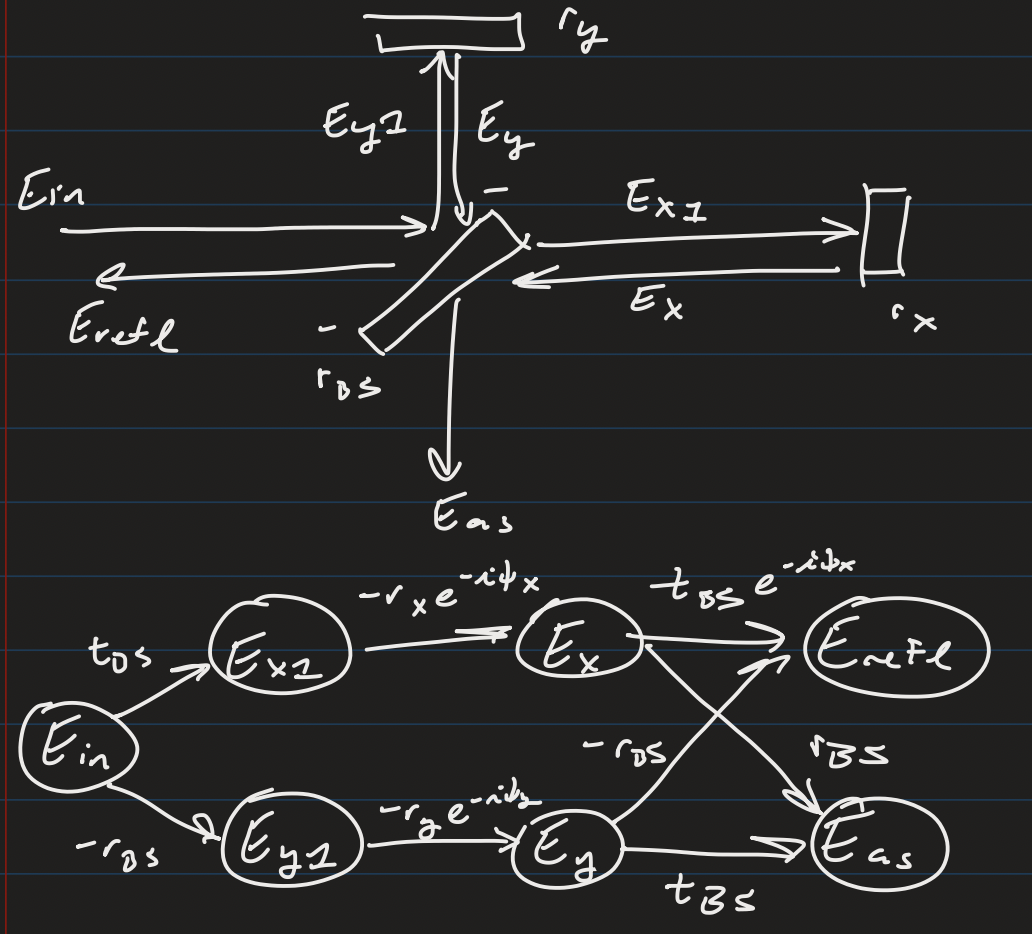

This is the same setup as in class, with the following adjacency matrix:
\begin{equation}
\begin{bmatrix}
E_{in} \\
E_x \\
E_y \\
E_{refl} \\
E_{as} \\
\end{bmatrix} = 
\begin{bmatrix}
0 & 0 & 0 & 0 & 0 \\
-t_{bs}r_xe^{-i\phi_x} & 0 & 0 & 0 & 0 \\
r_{bs}r_ye^{-i\phi_y} & 0 & 0 & 0 & 0 \\
0 & t_{bs}e^{-i\phi_x} & -r_{bs}e^{-i\phi_y} & 0 & 0 \\
0 & r_{bs}e^{-i\phi_x} & t_{bs}e^{-i\phi_y} & 0 & 0 \\
\end{bmatrix}
\begin{bmatrix}
E_{in} \\
E_x \\
E_y \\
E_{refl} \\
E_{as} \\
\end{bmatrix}
\end{equation}
This matrix is inverted to solve for the transfer functions below.

In [10]:
# set up the adjacency matrix
r_bs, t_bs, r_x, r_y = sympy.symbols(r'r_{bs} t_{bs} r_x r_y', positive=True)
phi_x, phi_y = sympy.symbols(r'\phi_x \phi_y', real=True)

# adjacency matrix I - M
mat = sympy.Matrix([[1, 0, 0, 0, 0],
                    [t_bs*r_x*sympy.exp(-1j*phi_x), 1, 0, 0, 0],
                    [-r_bs*r_y*sympy.exp(-1j*phi_y), 0, 1, 0, 0],
                    [0, -t_bs*sympy.exp(-1j*phi_x), r_bs*sympy.exp(-1j*phi_y), 1, 0],
                    [0, -r_bs*sympy.exp(-1j*phi_x), -t_bs*sympy.exp(-1j*phi_y), 0, 1]])

mat

Matrix([
[                             1,                          0,                          0, 0, 0],
[ r_x*t_{bs}*exp(-1.0*I*\phi_x),                          1,                          0, 0, 0],
[-r_y*r_{bs}*exp(-1.0*I*\phi_y),                          0,                          1, 0, 0],
[                             0, -t_{bs}*exp(-1.0*I*\phi_x),  r_{bs}*exp(-1.0*I*\phi_y), 1, 0],
[                             0, -r_{bs}*exp(-1.0*I*\phi_x), -t_{bs}*exp(-1.0*I*\phi_y), 0, 1]])

In [11]:
# invert
mat**-1

Matrix([
[                                                                                                                 1,                         0,                          0, 0, 0],
[                                                                                    -r_x*t_{bs}*exp(-1.0*I*\phi_x),                         1,                          0, 0, 0],
[                                                                                     r_y*r_{bs}*exp(-1.0*I*\phi_y),                         0,                          1, 0, 0],
[        (-r_x*t_{bs}**2*exp(2.0*I*\phi_y) - r_y*r_{bs}**2*exp(2.0*I*\phi_x))*exp(-2.0*I*\phi_x)*exp(-2.0*I*\phi_y), t_{bs}*exp(-1.0*I*\phi_x), -r_{bs}*exp(-1.0*I*\phi_y), 1, 0],
[(-r_x*r_{bs}*t_{bs}*exp(2.0*I*\phi_y) + r_y*r_{bs}*t_{bs}*exp(2.0*I*\phi_x))*exp(-2.0*I*\phi_x)*exp(-2.0*I*\phi_y), r_{bs}*exp(-1.0*I*\phi_x),  t_{bs}*exp(-1.0*I*\phi_y), 0, 1]])

Specifically, picking out the second, third, and fifth elements from the first column give the transfer functions for $E_x$, $E_y$, and $E_{as}$ respectively:
\begin{align}
\frac{E_x}{E_{in}} &= -r_xt_{bs}e^{-i\phi_x} \\
\frac{E_y}{E_{in}} &= r_yr_{bs}e^{-i\phi_y} \\
\frac{E_{as}}{E_{in}} &= -r_xr_{bs}t_{bs}e^{-2i\phi_x} + r_yr_{bs}t_{bs}e^{-2i\phi_y}. \\
\end{align}

## End Mirror Modulation
Now, suppose we apply some common modulation to both end mirrors:
$$\phi_c(t) = \phi_x(t) = \phi_y(t) = \Gamma \cos(\omega t)$$
Write what the new arm reflected transfer functions are for:
$$\dfrac{E_\mathrm{x}}{E_\mathrm{in}}, \dfrac{E_\mathrm{y}}{E_\mathrm{in}}$$
*Hint: Remember that you should end up with three distinct fields at $\omega_0$ and $\omega_0 \pm \omega$* 

The transfer functions for the arm fields can be read off by substituting $\phi \rightarrow \phi + \Gamma \cos \omega t$ and applying the Jacobi-Anger expansion to first order. In the case of the $X$ arm:
\begin{align}
\frac{E_x}{E_{in}} &= -r_xt_{bs}e^{-i\phi_x}e^{-i\Gamma\cos\omega t} \\
&= -r_xt_{bs}e^{-i\phi_x}\bigg[ 1 + i\Gamma e^{i\omega t} + i\Gamma e^{-i\omega t} \bigg]
\end{align}
Similarly for the $Y$ arm:
$$\frac{E_y}{E_{in}} = r_yr_{bs}e^{-i\phi_y}\bigg[ 1 + i\Gamma e^{i\omega t} + i\Gamma e^{-i\omega t} \bigg]$$

## Propagate to the antisymmetric port
Propagate your new transfer functions to the antisymmetric port, 
and compute a new $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$.

Be careful here.  
Consider carefully what $k = \omega/c$ is for each of your electric fields as they propagate back to the beamsplitter, accruing some phase $\phi = -k L$.\
Should each field accrue the same phase?

The modulation causes the indicent field to split into three, each with a different frequency and subsequently a different wavenumber. The carrier field has a wavenumber $k = \omega_0/c$ throughout the interferometer. However, the upper sideband will have a wavenumber of $k_+ = (\omega_0+\omega)/c$, which will accrue a phase $k_+L$ on only the return trip to the beam splitter. Thus, on the returning trip returning trip, the upper sideband will accrue a total phase of
\begin{align}
\phi_+ &= - L(\omega_0 + \omega)/c \\
&= - L\omega_0(1 + \omega/\omega_0)/c \\
\phi_+ &= - kL(1 + \omega/\omega_0). \\
\end{align}
Similarly for the lower sideband,
$$\phi_- = - kL(1 - \omega/\omega_0).$$
We can then propagate the arm fields by adding the appropriate beamsplitter factors and adding the factors of $e^{i\phi_{\pm}}$ as necessary:
\begin{align}
\frac{E_{as}}{E_{in}} &= -r_xr_{bs}t_{bs}e^{-i\phi_x}\bigg[ e^{-i\phi_x} + i\Gamma e^{i\omega t}e^{-i\phi_{x,+}} + i\Gamma e^{-i\omega t}e^{-i\phi_{x,-}} \bigg] + r_yr_{bs}t_{bs}e^{-i\phi_y}\bigg[ e^{-i\phi_y} + i\Gamma e^{i\omega t}e^{-i\phi_{y,+}} + i\Gamma e^{-i\omega t}e^{-i\phi_{y,-}} \bigg] \\
&= -r_xr_{bs}t_{bs}e^{-i\phi_x}\bigg[ e^{-i\phi_x} + i\Gamma e^{i\omega t}e^{-i\phi_x(1 + \omega/\omega_0)} + i\Gamma e^{-i\omega t}e^{-i\phi_x(1 - \omega/\omega_0)} \bigg] + r_yr_{bs}t_{bs}e^{-i\phi_y}\bigg[ e^{-i\phi_y} + i\Gamma e^{i\omega t}e^{-i\phi_y(1 + \omega/\omega_0)} + i\Gamma e^{-i\omega t}e^{-i\phi_y(1 - \omega/\omega_0)} \bigg] \\
&= -r_xr_{bs}t_{bs}e^{-2i\phi_x}\bigg[ 1 + i\Gamma e^{i\omega t}e^{-i\phi_x\omega/\omega_0} + i\Gamma e^{-i\omega t}e^{i\phi_x\omega/\omega_0} \bigg] + r_yr_{bs}t_{bs}e^{-2i\phi_y}\bigg[ 1 + i\Gamma e^{i\omega t}e^{-i\phi_y\omega/\omega_0} + i\Gamma e^{-i\omega t}e^{i\phi_y\omega/\omega_0} \bigg] \\
&= -r_xr_{bs}t_{bs}e^{-2i\phi_x}\bigg[ 1 + 2i\Gamma \cos(\omega t - \phi_x\omega/\omega_0) \bigg] + r_yr_{bs}t_{bs}e^{-2i\phi_y}\bigg[ 1 + 2i\Gamma \cos(\omega t - \phi_y\omega/\omega_0) \bigg]
\end{align}

## Calculate the power response
Calculate the power response to the common motion 
$\dfrac{P_\mathrm{as}}{P_\mathrm{in}}$.

This is a lot of algebra, I recommend *Mathematica* or *sympy* to help you make sure you get things right here.\
You may find it useful to express your arm phases in the common and differential bases again, since you have already incorporated the time-dependent term $\Gamma \cos(\omega t)$ as two additional sideband terms:
$$\phi_x = \phi_c + \phi_d, \qquad \phi_y = \phi_c - \phi_d$$

You may assume an ideal beamsplitter
$$r_\mathrm{bs} = t_\mathrm{bs} = \dfrac{1}{\sqrt{2}}$$
and balanced arms
$$r_\mathrm{x} = t_\mathrm{y}$$
and small modulation from the end mirrors
$$\Gamma^2 \approx 0$$

*Answer:*
$$
\dfrac{P_\mathrm{as}}{P_\mathrm{in}} = r_x^2 \left[ 
  \sin^2(2 \phi_d) - 2 \Gamma \sin (4 \phi_d) \sin \left(\dfrac{\omega \phi_d}{\omega_0}\right) \sin     \left(\omega t+\frac{\omega \phi_c}{\omega_0}\right) 
\right]
$$

Making the simplifications and change of basis above:
\begin{align}
\frac{E_{as}}{E_{in}} &= \frac{1}{2}r_x \bigg[-e^{-2i\phi_c}e^{-2i\phi_d}\bigg( 1 + 2i\Gamma \cos(\omega t - (\phi_c + \phi_d)\omega/\omega_0) \bigg) + e^{-2i\phi_c}e^{2i\phi_d}\bigg( 1 + 2i\Gamma \cos(\omega t - (\phi_c - \phi_d)\omega/\omega_0) \bigg) \bigg]\\
\end{align}

The modulus is taken below.

In [12]:
gamma, omega, omega_0, phi_c, phi_d, t, r_x = sympy.symbols(r'\Gamma \omega \omega_0 \phi_c \phi_d t r_x', real=True, positive=True)
ex = -(sympy.cos(2*(phi_c+phi_d)) - 1j*sympy.sin(2*(phi_c+phi_d)))*(1 + 2j*gamma*sympy.cos(omega*t - (phi_c + phi_d)*omega/omega_0)) 
ey = (sympy.cos(2*(phi_c-phi_d)) - 1j*sympy.sin(2*(phi_c-phi_d)))*(1 + 2j*gamma*sympy.cos(omega*t - (phi_c - phi_d)*omega/omega_0)) 
E_as = 0.5 * r_x * (ex + ey)
sympy.simplify(sympy.simplify(sympy.simplify(sympy.Abs(E_as)**2)))

r_x**2*(1.0*\Gamma**2*sin(2*\phi_c - 2*\phi_d)**2*cos(\omega*(\omega_0*t - \phi_c + \phi_d)/\omega_0)**2 - 2.0*\Gamma**2*sin(2*\phi_c - 2*\phi_d)*sin(2*\phi_c + 2*\phi_d)*cos(\omega*(-\omega_0*t + \phi_c + \phi_d)/\omega_0)*cos(\omega*(\omega_0*t - \phi_c + \phi_d)/\omega_0) + 1.0*\Gamma**2*sin(2*\phi_c + 2*\phi_d)**2*cos(\omega*(-\omega_0*t + \phi_c + \phi_d)/\omega_0)**2 + 1.0*\Gamma**2*cos(\omega*(-\omega_0*t + \phi_c + \phi_d)/\omega_0)**2*cos(2*\phi_c + 2*\phi_d)**2 - 2.0*\Gamma**2*cos(\omega*(-\omega_0*t + \phi_c + \phi_d)/\omega_0)*cos(\omega*(\omega_0*t - \phi_c + \phi_d)/\omega_0)*cos(2*\phi_c - 2*\phi_d)*cos(2*\phi_c + 2*\phi_d) + 1.0*\Gamma**2*cos(\omega*(\omega_0*t - \phi_c + \phi_d)/\omega_0)**2*cos(2*\phi_c - 2*\phi_d)**2 + 1.0*\Gamma*sin(2*\phi_c - 2*\phi_d)*cos(\omega*(-\omega_0*t + \phi_c + \phi_d)/\omega_0)*cos(2*\phi_c + 2*\phi_d) - 1.0*\Gamma*sin(2*\phi_c - 2*\phi_d)*cos(\omega*(\omega_0*t - \phi_c + \phi_d)/\omega_0)*cos(2*\phi_c + 2*\phi_d) - 1.0*\Gamma*sin(2*\phi

The above terms that have no dependence on $\Gamma$ reduce down to $\sin^2 (2\phi_d)$. Collecting the rest of the terms with at most linear dependence on $\Gamma$:
\begin{align}
\frac{P_{as}}{P_{in}} &= r_x^2\bigg[ \Gamma \sin(2(\phi_c - \phi_d))\cos(2(\phi_c + \phi_d)) \bigg( \cos\bigg( -\omega t + \frac{\omega}{\omega_0}(\phi_c + \phi_d) \bigg) - \cos\bigg( \omega t - \frac{\omega}{\omega_0}(\phi_c - \phi_d) \bigg) \bigg) \\
& - \Gamma \sin(2(\phi_c + \phi_d))\cos(2(\phi_c - \phi_d))\bigg(\cos\bigg( -\omega t + \frac{\omega}{\omega_0}(\phi_c + \phi_d) \bigg) - \cos\bigg( -\omega t + \frac{\omega}{\omega_0}(\phi_c - \phi_d)\bigg) \bigg) \\
& + \sin^2(2\phi_d) \bigg]
\end{align}
There's probably a series of trig idenities that Sympy didn't feel like doing that reduces to the expression given above. Examining this result, this does seem to have terms with the correct dependences on the given quantities to somehow lead to that.

## Demodulate the power term
Calculate 
$$P_\mathrm{as}^\mathrm{DC}, \, P_\mathrm{as}^I, \, P_\mathrm{as}^Q$$
by integrating $P_\mathrm{as}$ over one cycle of $\omega t$ while multiplying by $1, \cos(\omega t)$ and $\sin(\omega t)$, respectively.

Does your answer for $P_\mathrm{as}^\mathrm{DC}$ seem familiar?

From here we'll set $\theta = \omega t$ to simplify the notation. Calculating the DC power:
\begin{align}
P_{as}^{DC} &= \frac{1}{2\pi} \int_0^{2\pi} r_x^2 \bigg[ \sin^2(2 \phi_d) - 2 \Gamma \sin (4 \phi_d) \sin\bigg(\frac{\omega \phi_d }{\omega_0}\bigg) \sin\bigg(\theta+\frac{\omega \phi_c}{\omega_0}\bigg) \bigg] d\theta \\
&= r_x^2 \sin^2(2\phi_d).
\end{align}

If we assume highly reflective mirrors $r_x \approx 1$, this result resembles the total transmitted power of an asymmetric Michelson. Starting from Eq. 15 in the notes:
\begin{align}
\dfrac{E_\mathrm{trans}}{E_\mathrm{in}} &= - i e^{-i \phi_c} \sin(\phi_d) \\
\dfrac{P_\mathrm{trans}}{P_\mathrm{in}} &= \sin^2(\phi_d).
\end{align}
The factor of 2 difference is due to the difference in the definition of $\phi_d$ between the lectures ($\phi_x - \phi_y$) and this homework ($(\phi_x - \phi_y)/2$).

Calculating the $I$ quadrature:
\begin{align}
P_{as}^{I} &= \frac{1}{2\pi} \int_0^{2\pi} r_x^2 \bigg[ \sin^2(2 \phi_d) - 2 \Gamma \sin (4 \phi_d) \sin\bigg(\frac{\omega \phi_d }{\omega_0}\bigg) \sin\bigg(\theta+\frac{\omega \phi_c}{\omega_0}\bigg) \bigg] \cos\theta d\theta \\
&= -\frac{r_x^2\Gamma}{\pi}\sin (4 \phi_d) \sin\bigg(\frac{\omega \phi_d }{\omega_0}\bigg)\int_0^{2\pi}\sin\bigg(\theta+\frac{\omega \phi_c}{\omega_0}\bigg) \cos\theta d\theta \\
&= -r_x^2\Gamma\sin (4 \phi_d) \sin\bigg(\frac{\omega \phi_d }{\omega_0}\bigg)\sin\bigg(\frac{\omega \phi_c}{\omega_0}\bigg). \\
\end{align}

Calculating the $Q$ quadrature:
\begin{align}
P_{as}^{Q} &= \frac{1}{2\pi} \int_0^{2\pi} r_x^2 \bigg[ \sin^2(2 \phi_d) - 2 \Gamma \sin (4 \phi_d) \sin\bigg(\frac{\omega \phi_d }{\omega_0}\bigg) \sin\bigg(\theta+\frac{\omega \phi_c}{\omega_0}\bigg) \bigg] \sin\theta d\theta \\
&= -\frac{r_x^2\Gamma}{\pi}\sin (4 \phi_d) \sin\bigg(\frac{\omega \phi_d }{\omega_0}\bigg)\int_0^{2\pi}\sin\bigg(\theta+\frac{\omega \phi_c}{\omega_0}\bigg) \sin\theta d\theta \\
&= -r_x^2\Gamma\sin (4 \phi_d) \sin\bigg(\frac{\omega \phi_d }{\omega_0}\bigg)\cos\bigg(\frac{\omega \phi_c}{\omega_0}\bigg). \\
\end{align}

In [13]:
# do the trig parts of the integrals above
x, a = sympy.symbols('x a')
sympy.integrate(sympy.sin(x + a), (x, 0, 2*sympy.pi))

0

In [14]:
sympy.integrate(sympy.sin(x + a) * sympy.cos(x), (x, 0, 2*sympy.pi))

pi*sin(a)

In [15]:
sympy.integrate(sympy.sin(x + a) * sympy.sin(x), (x, 0, 2*sympy.pi))

pi*cos(a)

## Caluculate the Frequency Response to CARM motion in an Asymmetric Michelson
Calculate the frequency response
$$ P_\mathrm{as}(\omega) = P_\mathrm{as}^I(\omega) + i P_\mathrm{as}^Q(\omega)$$
to CARM motion $\Gamma$.

Plot the magnitude and phase for $\dfrac{P_\mathrm{as}}{\Gamma}(\omega)$.

Assume 
\begin{align}
r_x &= 1\\
L_x &= 1000~\mathrm{m}\\
L_y &= 1~\mathrm{m}\\
\lambda &= 1064~\mathrm{nm}
\end{align}

Taking the components calculated above:
\begin{align}
P_{as}(\omega) &= -r_x^2\Gamma\sin (4 \phi_d) \sin\bigg(\frac{\omega \phi_d }{\omega_0}\bigg) \bigg[ \sin\bigg(\frac{\omega \phi_c}{\omega_0}\bigg) + i\cos\bigg(\frac{\omega \phi_c}{\omega_0}\bigg) \bigg] \\
&= -ir_x^2\Gamma\sin (4 \phi_d) \sin\bigg(\frac{\omega \phi_d }{\omega_0}\bigg)e^{-i\omega\phi_c/\omega_0}
\end{align}

In [16]:
def tf(omega):
    '''The transfer function calculated above'''
    c = 3e8 # speed of light
    lam = 1064e-9 # the wavelength of carrier field
    k = 2*np.pi/lam # wavenumber of carrier field
    omega_0 = c*k # frequency of carrier field
    Lx = 1000 # length of X
    Ly = 1 # length of Y
    phi_c = k*(Lx + Ly)/2 # CARM offset
    phi_d = k*(Lx - Ly)/2 # DARM offset
    return -1j * np.sin(4*phi_d)*np.sin(omega*phi_d/omega_0)*np.exp(-1j*omega*phi_c/omega_0)

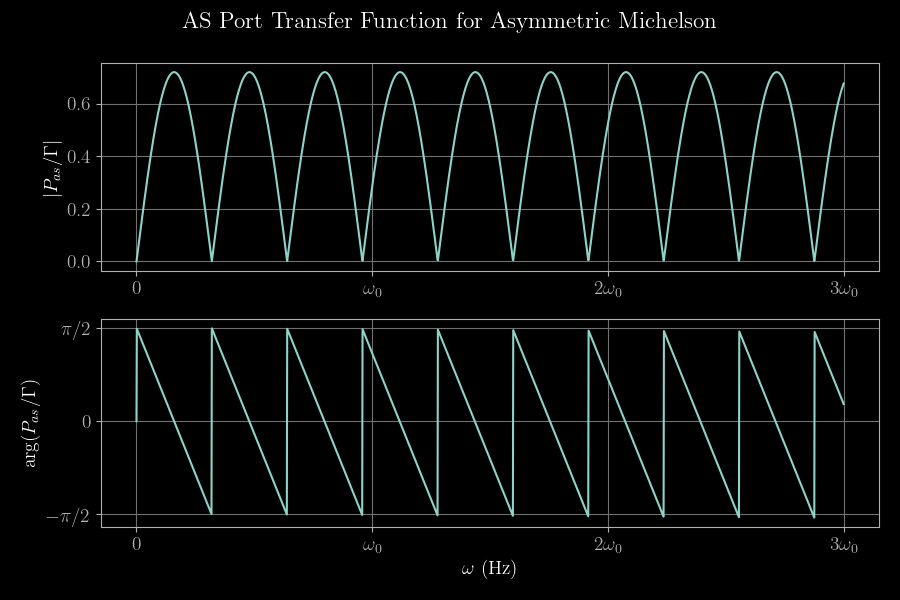

In [17]:
ref = 2*np.pi/1064e-9 # plot relative to the carrier frequency
omegas = np.linspace(0, 3*ref, 2000)
plt.close()

fig, ax = plt.subplots(2)
ax[0].plot(omegas, abs(tf(omegas)))
ax[1].plot(omegas, np.arctan2(tf(omegas).imag, tf(omegas).real))
ax[1].set_yticks([-np.pi/2, 0, np.pi/2], [r'$-\pi/2$', 0, r'$\pi/2$'])

for i in range(2):
    ax[i].set_xticks([0, ref, 2*ref, 3*ref], [0, r'$\omega_0$', r'$2\omega_0$', r'$3\omega_0$'])

ax[0].set_ylabel(r'$|P_{as}/\Gamma|$')
ax[1].set_ylabel(r'$\mathrm{arg}(P_{as}/\Gamma)$')
ax[1].set_xlabel(r'$\omega$ (Hz)')

fig.suptitle('AS Port Transfer Function for Asymmetric Michelson')

ax[0].grid()
ax[1].grid()

In [18]:
!pwd

/Users/alcorrei/Desktop/courses/lasers-and-optomechanics-homework/hw3
